# Interpretacion de Importancias - Sprint 3

Este notebook interpreta las tablas finales de importancias generadas en la Fase 1:

- `data/processed/13_feature_audit_lightgbm.parquet`
- `data/processed/13_feature_audit_xgboost.parquet`

Objetivos:

- revisar importancias baseline vs tuneado por modelo
- comparar LightGBM vs XGBoost
- identificar variables mas estables, variables que suben y variables que bajan
- dejar una lectura defendible para la presentacion

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

project_root = Path.cwd().resolve()
if not (project_root / 'data').exists():
    for candidate in [project_root, *project_root.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            project_root = candidate
            break

LIGHTGBM_PATH = project_root / 'data' / 'processed' / '13_feature_audit_lightgbm.parquet'
XGBOOST_PATH = project_root / 'data' / 'processed' / '13_feature_audit_xgboost.parquet'

print('project_root:', project_root)
print('lightgbm:', LIGHTGBM_PATH)
print('xgboost:', XGBOOST_PATH)

project_root: /var/www/codigo/maestria_ia/umsa/mod_13/miadas_mod_13_scrum
lightgbm: /var/www/codigo/maestria_ia/umsa/mod_13/miadas_mod_13_scrum/data/processed/13_feature_audit_lightgbm.parquet
xgboost: /var/www/codigo/maestria_ia/umsa/mod_13/miadas_mod_13_scrum/data/processed/13_feature_audit_xgboost.parquet


In [2]:
lgbm_df = pd.read_parquet(LIGHTGBM_PATH)
xgb_df = pd.read_parquet(XGBOOST_PATH)

display(lgbm_df.head())
display(xgb_df.head())

,Nro,Dominio,Variable,flagSelected,importancia_seleccion,importancia_modelo_final,modelo
0,1,customers,customer_unique_id,0,0.000000,0.000000,lightgbm
1,2,target,is_premium,0,0.000000,0.000000,lightgbm
2,3,orders,total_orders,1,0.026667,0.116498,lightgbm
3,4,order_items_products,total_items,1,4.053333,4.122233,lightgbm
4,5,order_items_products,total_products,1,0.320000,0.376378,lightgbm


,Nro,Dominio,Variable,flagSelected,importancia_seleccion,importancia_modelo_final,modelo
0,1,customers,customer_unique_id,0,0.000000,0.000000,xgboost
1,2,target,is_premium,0,0.000000,0.000000,xgboost
2,3,orders,total_orders,1,0.218142,0.221236,xgboost
3,4,order_items_products,total_items,1,3.278041,3.683963,xgboost
4,5,order_items_products,total_products,1,3.360487,2.137786,xgboost


## 1. Validacion rapida de estructura

In [3]:
expected_cols = [
    'Nro',
    'Dominio',
    'Variable',
    'flagSelected',
    'importancia_seleccion',
    'importancia_modelo_final',
    'modelo',
]

print('Columnas LightGBM OK:', list(lgbm_df.columns) == expected_cols)
print('Columnas XGBoost OK:', list(xgb_df.columns) == expected_cols)
print('Filas LightGBM:', len(lgbm_df))
print('Filas XGBoost:', len(xgb_df))

context_mask = lgbm_df['flagSelected'] == 0
display(lgbm_df.loc[context_mask, ['Variable', 'importancia_seleccion', 'importancia_modelo_final']])

Columnas LightGBM OK: True
Columnas XGBoost OK: True
Filas LightGBM: 30
Filas XGBoost: 30


,Variable,importancia_seleccion,importancia_modelo_final
0,customer_unique_id,0.0,0.0
1,is_premium,0.0,0.0


## 2. Tablas ordenadas por importancia final

In [4]:
def ranked_table(df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
    ranked = df[df['flagSelected'] == 1].copy()
    ranked['delta_tuning'] = ranked['importancia_modelo_final'] - ranked['importancia_seleccion']
    return ranked.sort_values('importancia_modelo_final', ascending=False).head(top_n)

display(ranked_table(lgbm_df, 15))
display(ranked_table(xgb_df, 15))

,Nro,Dominio,Variable,flagSelected,importancia_seleccion,importancia_modelo_final,modelo,delta_tuning
27,28,order_items_products,top_category,1,29.213333,21.982256,lightgbm,-7.231077
12,13,orders,recency_days,1,16.413333,21.023389,lightgbm,4.610056
7,8,orders,avg_estimated_delivery_days,1,9.760000,10.619231,lightgbm,0.859231
6,7,orders,avg_delivery_days,1,7.253333,8.531230,lightgbm,1.277897
21,22,features_derivadas,delivery_gap,1,5.400000,6.729994,lightgbm,1.329994
11,12,order_payments,max_payment_installments,1,7.373333,6.640380,lightgbm,-0.732953
25,26,customers,customer_state,1,3.866667,4.158079,lightgbm,0.291412
3,4,order_items_products,total_items,1,4.053333,4.122233,lightgbm,0.068900
5,6,order_reviews,avg_review_score,1,1.786667,2.643606,lightgbm,0.856939
28,29,features_derivadas,region_group,1,2.133333,2.240344,lightgbm,0.107011


,Nro,Dominio,Variable,flagSelected,importancia_seleccion,importancia_modelo_final,modelo,delta_tuning
27,28,order_items_products,top_category,1,38.046188,45.408630,xgboost,7.362442
18,19,features_derivadas,installments_gt_6_flag,1,27.665407,17.728516,xgboost,-9.936892
25,26,customers,customer_state,1,3.553595,8.191074,xgboost,4.637480
24,25,features_derivadas,top_category_is_high_value,1,4.662217,4.601341,xgboost,-0.060875
3,4,order_items_products,total_items,1,3.278041,3.683963,xgboost,0.405922
17,18,features_derivadas,installments_gt_1_flag,1,3.836737,3.261485,xgboost,-0.575252
11,12,order_payments,max_payment_installments,1,4.199539,3.130338,xgboost,-1.069201
26,27,order_payments,main_payment_type,1,3.476040,2.400960,xgboost,-1.075080
4,5,order_items_products,total_products,1,3.360487,2.137786,xgboost,-1.222701
8,9,orders,delivered_orders,1,1.828919,2.106951,xgboost,0.278032


## 3. Top variables por modelo

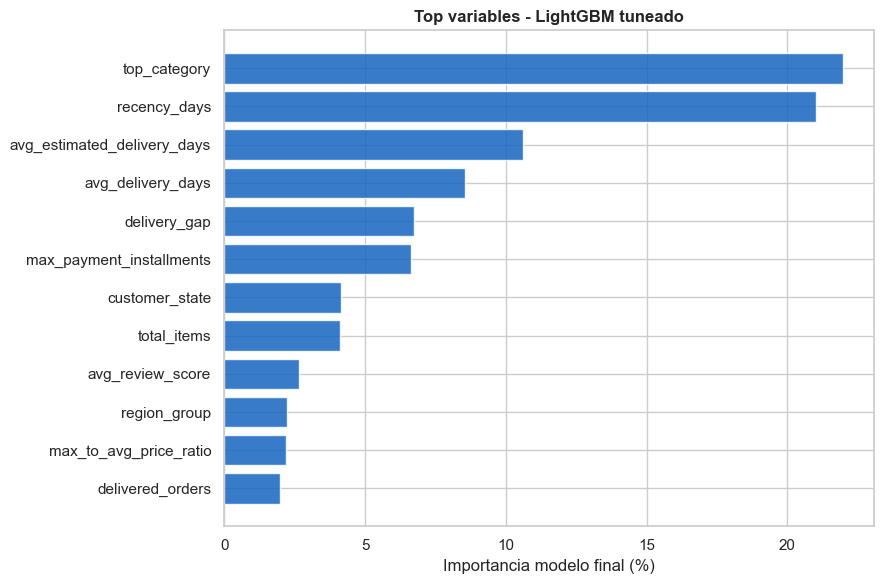

Lectura rapida: la variable con mayor peso final es 'top_category' con 21.98%.
Interpretacion: esta es la senal que el modelo esta priorizando mas en su version final.


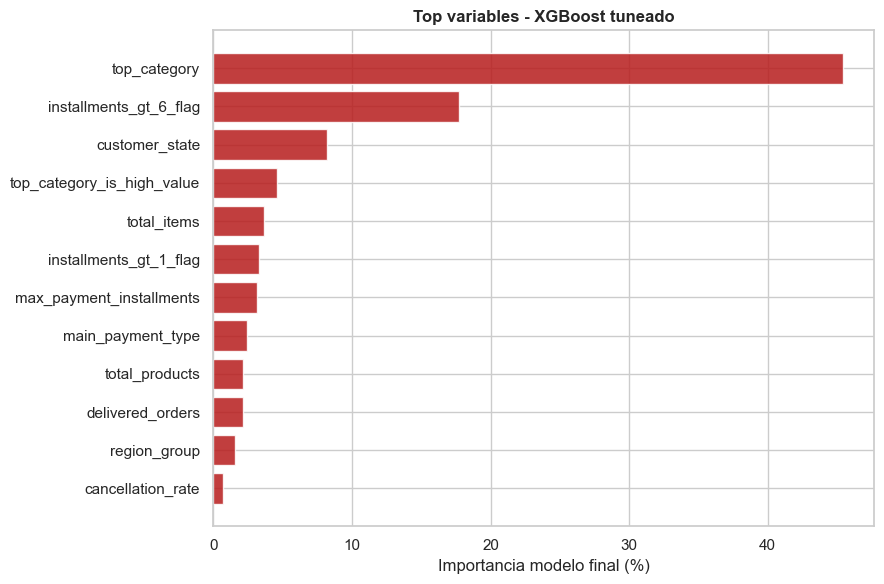

Lectura rapida: la variable con mayor peso final es 'top_category' con 45.41%.
Interpretacion: esta es la senal que el modelo esta priorizando mas en su version final.


In [5]:
def plot_top_final(df: pd.DataFrame, title: str, top_n: int = 12, color: str = '#1565C0') -> None:
    chart_df = ranked_table(df, top_n).sort_values('importancia_modelo_final', ascending=True)
    plt.figure(figsize=(9, 6))
    plt.barh(chart_df['Variable'], chart_df['importancia_modelo_final'], color=color, alpha=0.85)
    plt.xlabel('Importancia modelo final (%)')
    plt.title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()
    top_var = chart_df.iloc[-1]
    print(f"Lectura rapida: la variable con mayor peso final es '{top_var['Variable']}' con {top_var['importancia_modelo_final']:.2f}%.")
    print('Interpretacion: esta es la senal que el modelo esta priorizando mas en su version final.')

plot_top_final(lgbm_df, 'Top variables - LightGBM tuneado', color='#1565C0')
plot_top_final(xgb_df, 'Top variables - XGBoost tuneado', color='#B71C1C')

## 4. Cambio baseline vs tuneado dentro de cada modelo

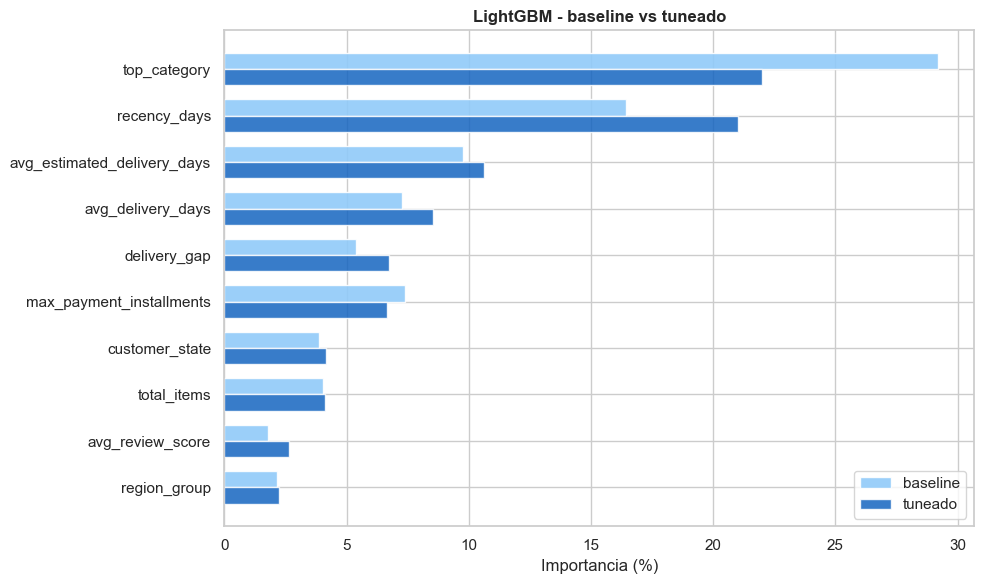

Lectura rapida: la variable que mas gana peso con tuning es 'recency_days' (+4.61 pp).
Lectura rapida: la variable que mas pierde peso con tuning es 'top_category' (-7.23 pp).
Interpretacion: si baseline y tuneado quedan muy parecidos, el tuning refina el modelo pero no cambia la historia principal.


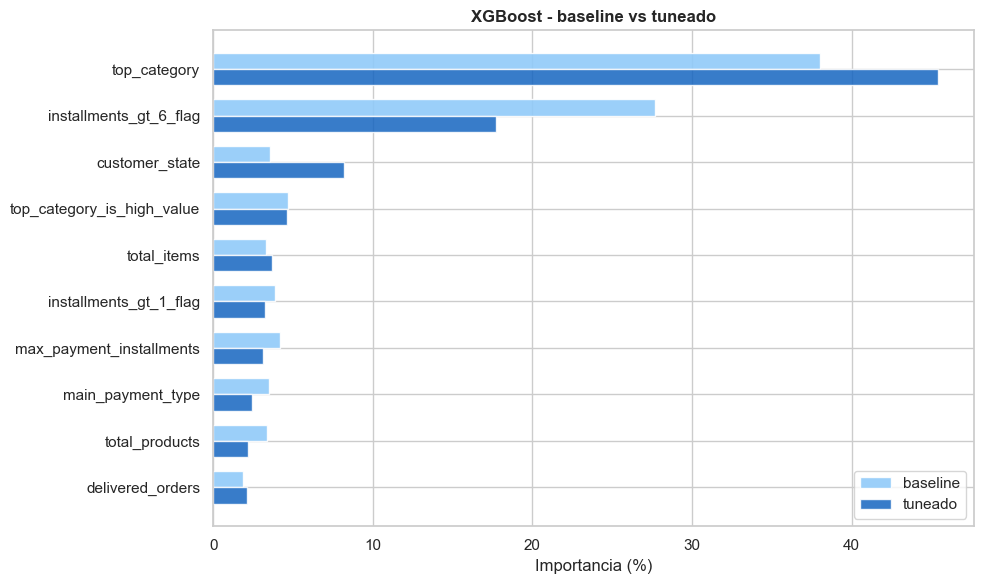

Lectura rapida: la variable que mas gana peso con tuning es 'top_category' (+7.36 pp).
Lectura rapida: la variable que mas pierde peso con tuning es 'installments_gt_6_flag' (-9.94 pp).
Interpretacion: si baseline y tuneado quedan muy parecidos, el tuning refina el modelo pero no cambia la historia principal.


In [6]:
def plot_baseline_vs_tuned(df: pd.DataFrame, title: str, top_n: int = 10) -> None:
    comp = ranked_table(df, top_n).sort_values('importancia_modelo_final', ascending=True).reset_index(drop=True)
    y = range(len(comp))
    bar_height = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        [i + bar_height / 2 for i in y],
        comp['importancia_seleccion'],
        height=bar_height,
        color='#90CAF9',
        alpha=0.9,
        label='baseline',
    )
    ax.barh(
        [i - bar_height / 2 for i in y],
        comp['importancia_modelo_final'],
        height=bar_height,
        color='#1565C0',
        alpha=0.85,
        label='tuneado',
    )
    ax.set_yticks(list(y))
    ax.set_yticklabels(comp['Variable'])
    ax.set_xlabel('Importancia (%)')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
    comp['delta_tuning'] = comp['importancia_modelo_final'] - comp['importancia_seleccion']
    rising = comp.sort_values('delta_tuning', ascending=False).iloc[0]
    falling = comp.sort_values('delta_tuning', ascending=True).iloc[0]
    print(f"Lectura rapida: la variable que mas gana peso con tuning es '{rising['Variable']}' ({rising['delta_tuning']:+.2f} pp).")
    print(f"Lectura rapida: la variable que mas pierde peso con tuning es '{falling['Variable']}' ({falling['delta_tuning']:+.2f} pp).")
    print('Interpretacion: si baseline y tuneado quedan muy parecidos, el tuning refina el modelo pero no cambia la historia principal.')

plot_baseline_vs_tuned(lgbm_df, 'LightGBM - baseline vs tuneado')
plot_baseline_vs_tuned(xgb_df, 'XGBoost - baseline vs tuneado')

In [7]:
def tuning_delta_table(df: pd.DataFrame, top_n: int = 10) -> tuple[pd.DataFrame, pd.DataFrame]:
    tmp = df[df['flagSelected'] == 1].copy()
    tmp['delta_tuning'] = tmp['importancia_modelo_final'] - tmp['importancia_seleccion']
    up = tmp.sort_values('delta_tuning', ascending=False).head(top_n)
    down = tmp.sort_values('delta_tuning', ascending=True).head(top_n)
    return up, down

lgbm_up, lgbm_down = tuning_delta_table(lgbm_df)
xgb_up, xgb_down = tuning_delta_table(xgb_df)

print('LightGBM - variables que mas suben')
display(lgbm_up[['Variable', 'importancia_seleccion', 'importancia_modelo_final', 'delta_tuning']])
print('LightGBM - variables que mas bajan')
display(lgbm_down[['Variable', 'importancia_seleccion', 'importancia_modelo_final', 'delta_tuning']])

print('XGBoost - variables que mas suben')
display(xgb_up[['Variable', 'importancia_seleccion', 'importancia_modelo_final', 'delta_tuning']])
print('XGBoost - variables que mas bajan')
display(xgb_down[['Variable', 'importancia_seleccion', 'importancia_modelo_final', 'delta_tuning']])

LightGBM - variables que mas suben


,Variable,importancia_seleccion,importancia_modelo_final,delta_tuning
12,recency_days,16.413333,21.023389,4.610056
21,delivery_gap,5.400000,6.729994,1.329994
6,avg_delivery_days,7.253333,8.531230,1.277897
7,avg_estimated_delivery_days,9.760000,10.619231,0.859231
5,avg_review_score,1.786667,2.643606,0.856939
16,max_to_avg_price_ratio,1.840000,2.186576,0.346576
25,customer_state,3.866667,4.158079,0.291412
28,region_group,2.133333,2.240344,0.107011
23,far_region_flag,0.466667,0.573528,0.106861
2,total_orders,0.026667,0.116498,0.089831


LightGBM - variables que mas bajan


,Variable,importancia_seleccion,importancia_modelo_final,delta_tuning
27,top_category,29.213333,21.982256,-7.231077
8,delivered_orders,3.493333,1.971503,-1.521831
11,max_payment_installments,7.373333,6.640380,-0.732953
19,credit_card_flag,0.813333,0.501837,-0.311496
22,reviews_per_order,0.520000,0.376378,-0.143622
26,main_payment_type,1.133333,1.039520,-0.093814
20,voucher_flag,0.213333,0.143382,-0.069951
24,top_category_is_high_value,1.680000,1.622009,-0.057991
9,late_deliveries,0.200000,0.152343,-0.047657
10,payment_methods_count,0.453333,0.439107,-0.014226


XGBoost - variables que mas suben


,Variable,importancia_seleccion,importancia_modelo_final,delta_tuning
27,top_category,38.046188,45.408630,7.362442
25,customer_state,3.553595,8.191074,4.637480
14,cancellation_rate,0.076583,0.657159,0.580576
28,region_group,1.113427,1.569787,0.456360
3,total_items,3.278041,3.683963,0.405922
8,delivered_orders,1.828919,2.106951,0.278032
10,payment_methods_count,0.244318,0.424179,0.179861
20,voucher_flag,0.197534,0.355795,0.158262
9,late_deliveries,0.086027,0.235441,0.149415
5,avg_review_score,0.112497,0.240861,0.128364


XGBoost - variables que mas bajan


,Variable,importancia_seleccion,importancia_modelo_final,delta_tuning
18,installments_gt_6_flag,27.665407,17.728516,-9.936892
4,total_products,3.360487,2.137786,-1.222701
26,main_payment_type,3.476040,2.400960,-1.075080
11,max_payment_installments,4.199539,3.130338,-1.069201
17,installments_gt_1_flag,3.836737,3.261485,-0.575252
19,credit_card_flag,0.964816,0.645429,-0.319387
23,far_region_flag,0.609467,0.491670,-0.117797
16,max_to_avg_price_ratio,0.500370,0.388008,-0.112362
7,avg_estimated_delivery_days,0.426791,0.355723,-0.071068
24,top_category_is_high_value,4.662217,4.601341,-0.060875


## 5. Comparacion directa LightGBM vs XGBoost

In [8]:
compare_df = lgbm_df[['Variable', 'Dominio', 'flagSelected', 'importancia_modelo_final']].merge(
    xgb_df[['Variable', 'importancia_modelo_final']],
    on='Variable',
    suffixes=('_lightgbm', '_xgboost'),
)
compare_df = compare_df[compare_df['flagSelected'] == 1].copy()
compare_df['delta_modelos'] = (
    compare_df['importancia_modelo_final_lightgbm']
    - compare_df['importancia_modelo_final_xgboost']
)
compare_df = compare_df.sort_values('importancia_modelo_final_lightgbm', ascending=False)
display(compare_df.head(15))

,Variable,Dominio,flagSelected,importancia_modelo_final_lightgbm,importancia_modelo_final_xgboost,delta_modelos
27,top_category,order_items_products,1,21.982256,45.408630,-23.426374
12,recency_days,orders,1,21.023389,0.331167,20.692222
7,avg_estimated_delivery_days,orders,1,10.619231,0.355723,10.263508
6,avg_delivery_days,orders,1,8.531230,0.306540,8.224690
21,delivery_gap,features_derivadas,1,6.729994,0.253915,6.476079
11,max_payment_installments,order_payments,1,6.640380,3.130338,3.510042
25,customer_state,customers,1,4.158079,8.191074,-4.032996
3,total_items,order_items_products,1,4.122233,3.683963,0.438270
5,avg_review_score,order_reviews,1,2.643606,0.240861,2.402745
28,region_group,features_derivadas,1,2.240344,1.569787,0.670557


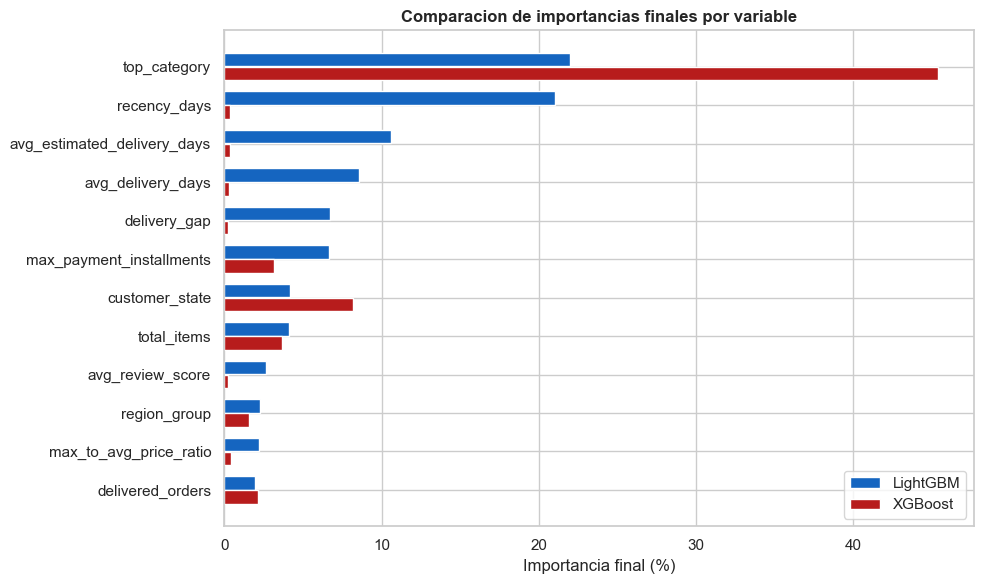

In [9]:
top_compare = compare_df.head(12).sort_values('importancia_modelo_final_lightgbm', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y = range(len(top_compare))
ax.barh([i + 0.18 for i in y], top_compare['importancia_modelo_final_lightgbm'], height=0.35, color='#1565C0', label='LightGBM')
ax.barh([i - 0.18 for i in y], top_compare['importancia_modelo_final_xgboost'], height=0.35, color='#B71C1C', label='XGBoost')
ax.set_yticks(list(y))
ax.set_yticklabels(top_compare['Variable'])
ax.set_xlabel('Importancia final (%)')
ax.set_title('Comparacion de importancias finales por variable', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Lectura por dominio

,Dominio,lightgbm_total,xgboost_total,variable_count
5,orders,43.059414,4.470039,8
2,order_items_products,26.480867,51.230381,3
1,features_derivadas,15.162649,29.571756,11
3,order_payments,8.119007,5.955476,3
0,customers,4.158079,8.191074,1
4,order_reviews,3.019984,0.581278,2


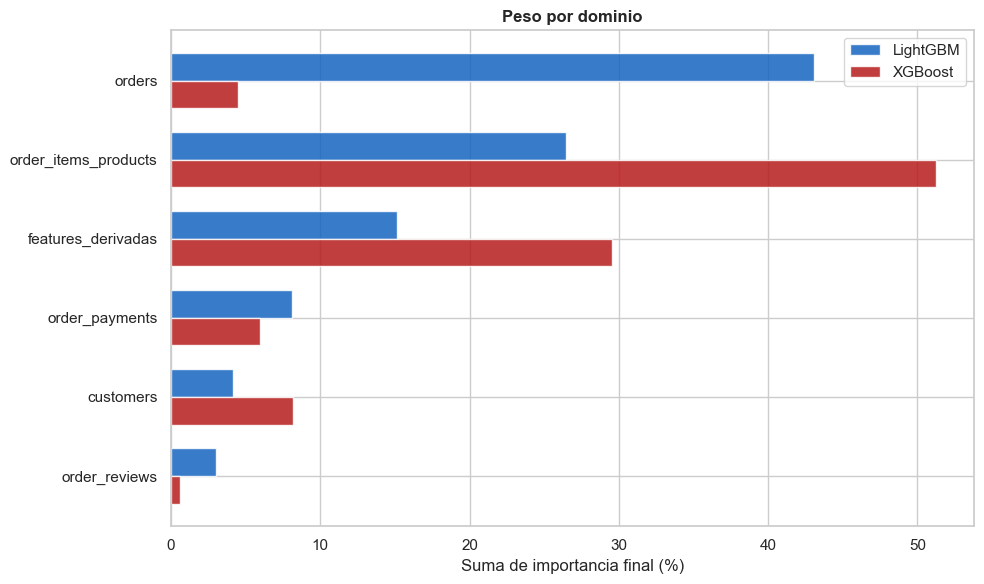

Lectura rapida LightGBM: el dominio con mas peso es 'orders' con 43.06%.
Lectura rapida XGBoost: el dominio con mas peso es 'order_items_products' con 51.23%.
Interpretacion: esto ayuda a defender si el modelo se apoya mas en comportamiento de ordenes, pagos, categorias o variables derivadas.


In [10]:
domain_summary = compare_df.groupby('Dominio', as_index=False).agg(
    lightgbm_total=('importancia_modelo_final_lightgbm', 'sum'),
    xgboost_total=('importancia_modelo_final_xgboost', 'sum'),
    variable_count=('Variable', 'count'),
).sort_values('lightgbm_total', ascending=False)

display(domain_summary)

domain_plot = domain_summary.sort_values('lightgbm_total', ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 6))
y = range(len(domain_plot))
bar_height = 0.35
ax.barh([i + bar_height / 2 for i in y], domain_plot['lightgbm_total'], height=bar_height, color='#1565C0', alpha=0.85, label='LightGBM')
ax.barh([i - bar_height / 2 for i in y], domain_plot['xgboost_total'], height=bar_height, color='#B71C1C', alpha=0.85, label='XGBoost')
ax.set_yticks(list(y))
ax.set_yticklabels(domain_plot['Dominio'])
ax.set_xlabel('Suma de importancia final (%)')
ax.set_title('Peso por dominio', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
top_lgbm = domain_summary.sort_values('lightgbm_total', ascending=False).iloc[0]
top_xgb = domain_summary.sort_values('xgboost_total', ascending=False).iloc[0]
print(f"Lectura rapida LightGBM: el dominio con mas peso es '{top_lgbm['Dominio']}' con {top_lgbm['lightgbm_total']:.2f}%.")
print(f"Lectura rapida XGBoost: el dominio con mas peso es '{top_xgb['Dominio']}' con {top_xgb['xgboost_total']:.2f}%.")
print('Interpretacion: esto ayuda a defender si el modelo se apoya mas en comportamiento de ordenes, pagos, categorias o variables derivadas.')

## 7. Conclusiones guiadas

Preguntas sugeridas para la defensa:

1. Que variables dominan en ambos modelos?
2. Que variables ganan peso despues del tuning?
3. El modelo final depende mas de variables de `orders`, `order_payments` o `features_derivadas`?
4. Hay variables categoricas agregadas como `top_category`, `customer_state` o `main_payment_type` que tengan un peso alto?
5. LightGBM y XGBoost cuentan la misma historia o priorizan senales distintas?